In [35]:
from keras.models import Sequential 
from keras.layers import Dense 
from keras.optimizers import Adam

In [36]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [37]:
splits = np.load("data/iris_splits.npz", allow_pickle=True)

X_sepal_train_std = splits["X_sepal_train_std"]
X_sepal_test_std  = splits["X_sepal_test_std"]
X_petal_train_std = splits["X_petal_train_std"]
X_petal_test_std  = splits["X_petal_test_std"]
X_train_combined = splits["X_train_combined"]
X_test_combined  = splits["X_test_combined"]
y_train = splits["y_train"]
y_test  = splits["y_test"]


In [38]:
import sys
sys.path.append("src")

from utils import plot_decision_regions

In [39]:
def create_network():
    model = Sequential()
    model.add(Dense(10, activation='relu', input_shape=(X_train_combined.shape[1],)))
    model.add(Dense(10, activation='relu'))
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [40]:
model = create_network()

C:\Users\Hobbs\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
# convert string labels to integer class indices
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# now fit the model with numeric labels
results = model.fit(
    X_train_combined, y_train_enc,
    epochs=100, batch_size=16,
    validation_data=(X_test_combined, y_test_enc)
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3250 - loss: 1.1073 - val_accuracy: 0.8000 - val_loss: 0.8964
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8333 - loss: 0.7912 - val_accuracy: 0.9333 - val_loss: 0.6586
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8750 - loss: 0.5763 - val_accuracy: 0.8000 - val_loss: 0.4867
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8667 - loss: 0.4119 - val_accuracy: 0.8000 - val_loss: 0.3779
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8583 - loss: 0.3061 - val_accuracy: 0.7667 - val_loss: 0.3308
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9083 - loss: 0.2551 - val_accuracy: 0.8333 - val_loss: 0.2879
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9000 - loss: 0.2205 - val_accuracy: 0.8667 - val_loss: 0.2556
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9167 - loss: 0.1845 - val_accuracy: 0.8667 - val_loss: 0.2314

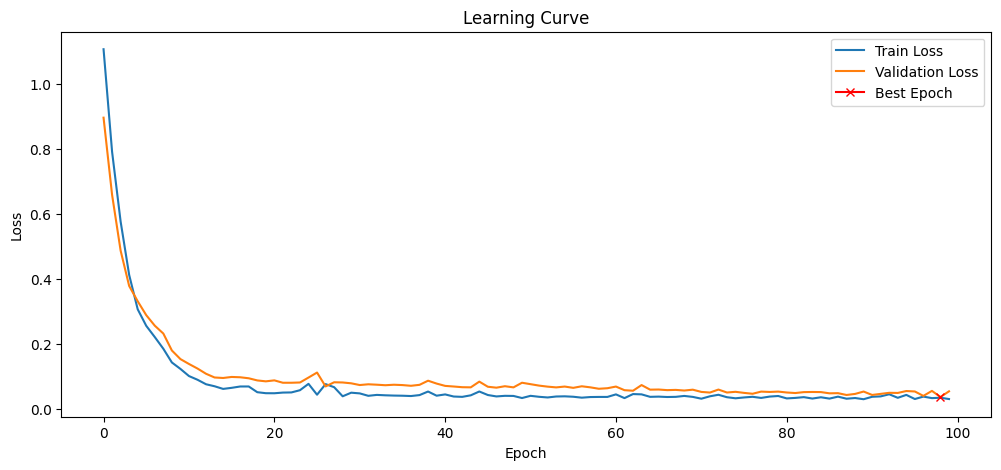

In [42]:
plt.figure(figsize=(12, 5))
plt.title("Learning Curve")
plt.plot(results.history["loss"], label="Train Loss")
plt.plot(results.history["val_loss"], label="Validation Loss")
plt.plot(np.argmin(results.history["val_loss"]), np.min(results.history["val_loss"]), marker="x", color="red", label="Best Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


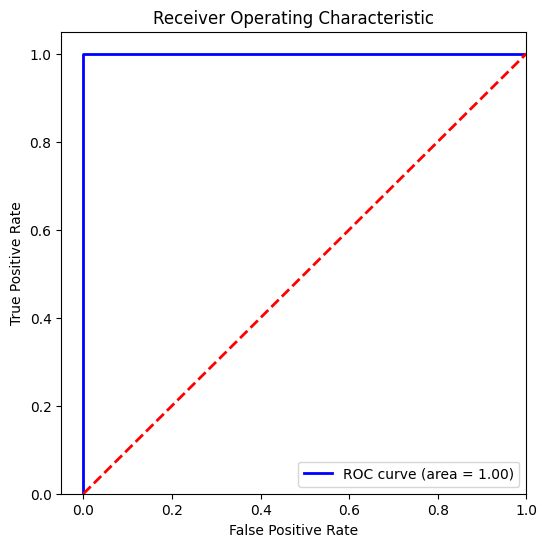

In [43]:
y_test_bin = label_binarize(y_test, classes=le.classes_)

y_test_bin = label_binarize(y_test, classes=le.classes_)

# get the probability estimates from the network
probas = model.predict(X_test_combined)

fpr, tpr, thresholds = roc_curve(
    y_test_bin[:, 1],       # select the positive class
    probas[:, 1]            # probabilities for that class
)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([-0.05, 1.0])   
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()